In [13]:
import os
import base64
import json
import random
from openai import OpenAI
import anthropic
import numpy as np
import re
from tqdm import tqdm
import pandas as pd
import time
import matplotlib.pyplot as plt
from word2number import w2n
from dotenv import load_dotenv
import copy

# Load dataset

In [14]:
# Set base directory using relative path
base_dir = os.path.join(os.getcwd(), "dataset", "simpsons")

# Set paths relative to base_dir
annotation_path = os.path.join(base_dir, "v1_Annotation_Val_simpsons_vqa.json")
question_path = os.path.join(base_dir, "v1_Question_Val_simpsons_vqa.json")
images_dir = os.path.join(base_dir, "val_images")

def load_dataset(annotation_path, question_path):
    try:
        with open(annotation_path, 'r') as f:
            annotations = json.load(f)['annotations']

        with open(question_path, 'r') as f:
            questions = json.load(f)['questions']

        # Select high-quality QA pairs (overall_scores == 1.0)
        filtered_annotations = [
            annotation for annotation in annotations
            if annotation.get('overall_scores', {}).get('question') == 1.0 and
               annotation.get('overall_scores', {}).get('answer') == 1.0
        ]

        # Create a mapping from question ID to answer
        question_id_to_answer = {
            annotation['id']: annotation['answer']
            for annotation in filtered_annotations
        }

        # Create a mapping from question ID to answer type
        question_id_to_answer_type = {
            annotation['id']: {
                'answer': annotation['answer'],
                'answer_type': annotation.get('answer_type', 'other')
            }
            for annotation in filtered_annotations
        }

        filtered_questions = [question for question in questions if question['id'] in question_id_to_answer]

        return filtered_questions, filtered_annotations, question_id_to_answer, question_id_to_answer_type

    except Exception as e:
        print(f"Error loading dataset: {e}")
        return [], [], {}, {}

def get_dataset(questions, question_id_to_answer, fraction=0.005, seed=42):
    # TODO：Increase quantity
# def get_dataset(questions, question_id_to_answer, fraction=0.05, seed=42):
    try:
        random.seed(seed)
        sample_size = max(1, int(len(questions) * fraction))
        sampled_question_items = random.sample(questions, sample_size)
        sampled_correct_answers = [
            question_id_to_answer[q['id']]
            for q in sampled_question_items
        ]
        # Add image_base64 to each sampled question
        for q in sampled_question_items:
            image_relative_path = q['img_path']
            image_path = os.path.join(images_dir, image_relative_path)
            q['image_base64'] = encode_image(image_path)

        return sampled_question_items, sampled_correct_answers

    except Exception as e:
        print(f"Error sampling dataset: {e}")
        return [], []

def encode_image(image_path):
    try:
        if not os.path.exists(image_path):
            print(f"Error: The image file at {image_path} was not found.")
            return None

        with open(image_path, "rb") as image_file:
            image_base64 = base64.b64encode(image_file.read()).decode('utf-8')
            return image_base64

    except Exception as e:
        print(f"An error occurred while encoding the image: {e}")
        return None

# Initialize results list
results_ablation = []

# Cache the initial dataset load to avoid repeated disk I/O
cached_dataset = None

# Function to get a fresh copy of the dataset
def get_fresh_dataset(reload=False):
    global cached_dataset
    if cached_dataset is None or reload:
        print("Loading dataset from disk...")
        # Load the dataset from disk
        questions, annotations, question_id_to_answer, question_id_to_answer_type = load_dataset(annotation_path, question_path)
        cached_dataset = {
            'questions': questions,
            'annotations': annotations,
            'question_id_to_answer': question_id_to_answer,
            'question_id_to_answer_type': question_id_to_answer_type
        }
    else:
        print("Using cached dataset but creating a deep copy to prevent contamination...")

    # Always return a deep copy to prevent cross-configuration contamination
    return copy.deepcopy(cached_dataset['questions']), \
           copy.deepcopy(cached_dataset['annotations']), \
           copy.deepcopy(cached_dataset['question_id_to_answer']), \
           copy.deepcopy(cached_dataset['question_id_to_answer_type'])

# Ablation Study Configuration
# Global variables for agent enablement, initialized here
ENABLE_VISUAL_AGENT = False
ENABLE_LANGUAGE_AGENT = False
ENABLE_CRITIC_AGENT = False


# Agents Configuration

In [ ]:
load_dotenv()
# Configuration
# MODEL_NAME = "claude-3-5-haiku-20241022"
MODEL_NAME = "gpt-4o-mini"

is_openai_model = not MODEL_NAME.startswith("claude-")

if is_openai_model:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    print(f"Using OpenAI model: {MODEL_NAME}")
else:
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    print(f"Using Anthropic model: {MODEL_NAME}")

# Agent Implementations

# Enhanced Visual agent that provides highly accurate and question-relevant descriptions
def visual_agent(image_base64, question, max_retries=3, retry_delay=2):
    # If visual agent is disabled, return a basic placeholder
    if not ENABLE_VISUAL_AGENT:
        return "This is a cartoon image from The Simpsons."

    prompt = f"""
    You are a Simpsons visual analysis expert specialized in interpreting The Simpsons cartoon style. 
    
    Your Task: Focus on answering the question: "{question}". Based on the cartoon image, describe ONLY the visual elements that help answer it. Be specific SPECIFIC and CONCISE.
    Generate a short, grounded visual description based on the image and the context below.
    
    Follow these Simpsons-specific guidelines:
    - Limit your description to ONE SENTENCE MAXIMUM.
    - Pay attention to the cartoon style and humor of The Simpsons.
    - Color: Include color directly relevant to the question.
    - Note the setting
    - Action: Describe visible actions or postures, like standing, sitting.
    - DIRECTLY ADDRESS the question being asked - if asked about color, focus on color; if asked about objects, focus on those specific objects.
    - For "what is/are" questions about objects, list matching items visible in the scene. VERY IMPORTANT: List items in order of quantity first.
    - Always prioritize the MAIN subject of the question.

    Special Instructions:
    - If the question refers to "man", "woman", "boy", "girl", but the visual evidence does not clearly indicate gender, assume the question refers to the person in focus. Focus on the attribute, NOT gender matching.
    - NEVER output "n/a", "unknown", or "none" as the answer.
    - If unsure, always attempt to provide a plausible answer related to the asked attribute (e.g., hair color, clothing).
        
    Important restrictions:
    - DO NOT include plot speculation or storyline interpretation beyond what is visible.
    - DO NOT include references to episodes or Simpsons lore not visible in the image.
    - DO NOT include: opinions, emotional or subjective language.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url",
                                 "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}},
                            ],
                        }
                    ],
                    max_tokens=500,
                    temperature=0.0,
                )
                visual_description = completion.choices[0].message.content.strip()
                return visual_description
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}},
                        ]
                    }],
                    max_tokens=500,
                    temperature=0.0,
                )
                visual_description = completion.content[0].text.strip()
                return visual_description

        except Exception as e:
            print(f"Visual agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Visual agent failed to process the image")
    return None

# Language agent: handles questions, and outputs initial predicted answer
def language_agent(question, image_base64, visual_description, max_retries=3, retry_delay=2):
    # If language agent is disabled, return None
    if not ENABLE_LANGUAGE_AGENT:
        return None

    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from The Simpsons."

    prompt = f"""
    As a cartoon language expert, answer the "{question}" concisely and accurately based on the provided context using EXACTLY ONE WORD:

    Evidence: 
    Visual Description: "{visual_description}"

    Guidelines: 
    - No explanations or punctuation allowed.
    - Do not answer "none", "n/a", "unknown" even if you are uncertain. Always attempt a plausible reasonable answer.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {
                                    "type": "image_url",
                                    "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
                                }
                            ],
                        }
                    ],
                    max_tokens=150,
                    temperature=0.0,
                )
                initial_answer = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}},
                        ]
                    }],
                    max_tokens=150,
                    temperature=0.0,
                )
                initial_answer = completion.content[0].text.strip().lower()

            # Process the response
            # Remove punctuation marks
            initial_answer = initial_answer.rstrip('.!?')

            # Split into words and get the first word
            words = initial_answer.split()
            if not words:
                continue

            initial_answer = words[0]

            # Convert numbers if applicable
            try:
                # Check if word represents a number
                number = w2n.word_to_num(initial_answer)
                initial_answer = str(number)
            except ValueError:
                # Check if contains numeric digits
                matches = re.findall(r'\d+', initial_answer)
                if matches:
                    initial_answer = matches[0]

            return initial_answer

        except Exception as e:
            print(f"Language agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Language agent failed to generate an answer")
    return None

def classify_question_type(question):
    question_lower = question.lower()

    # Color questions
    if any(word in question_lower for word in ['color', 'what color', 'blue', 'red', 'green', 'yellow', 'black', 'white']):
        return 'color'

    # Counting/numeric questions
    elif any(word in question_lower for word in ['how many', 'count', 'number']):
        return 'counting'

    # Action questions
    elif any(word in question_lower for word in ['doing', 'action', 'what is', 'what are', 'activity']):
        return 'action recognition'

    # Existence questions
    elif any(word in question_lower for word in ['is there', 'are there', 'does', 'do you see', 'can you']):
        return 'existence'

    # Location questions
    elif any(word in question_lower for word in ['where', 'location', 'place', 'position', 'on the', 'in the']):
        return 'location'

    # Default
    return 'other'

def critic_agent(question, image_base64, initial_answer, visual_description, max_retries=3, retry_delay=2, verbose=False):
    # If critic agent is disabled, return the initial prediction
    if not ENABLE_CRITIC_AGENT:
        return initial_answer, False, {}

    # Handle case when language_agent failed or was disabled
    if initial_answer is None:
        return "unknown", False, {}
    
    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from The Simpsons."
    force_poor_visual_description_quality = not ENABLE_VISUAL_AGENT
    question_type = classify_question_type(question)
    
    prompt = f"""
    As a cartoon critic expert. Focus on the question “{question}”, evaluate the initial answer "{initial_answer}" and provide a confident final answer based on the available evidence.

    Step 1: Assess the Visual Description quality:
    "{visual_description}"
    - If the description is clear, relevant, and helpful to answer the question, set:
    VISUAL_DESCRIPTION_QUALITY: GOOD  
    - If the description is ambiguous, irrelevant, or misleading, set:
    VISUAL_DESCRIPTION_QUALITY: POOR

    Step 2: Reasoning strategy:
    - If VISUAL_DESCRIPTION_QUALITY is GOOD, consider all available evidence including the visual description "{visual_description}" and image,
    - If VISUAL_DESCRIPTION_QUALITY is POOR, ignore the visual description "{visual_description}" and rely on your own analysis of the image.

    Note: If the VISUAL_DESCRIPTION_QUALITY is GOOD, you may give more weight to it in your decision, but still verify the conclusion with supporting evidence from the image or text.
     Special Instructions:
    - If the question refers to "man", "woman", "boy", "girl", but the visual evidence does not clearly indicate gender, assume the question refers to the person in focus. Focus on the attribute, NOT gender matching.
    - NEVER output "n/a", "unknown", or "none" as the answer.
    - If unsure, always attempt to provide a plausible answer related to the asked attribute (e.g., hair color, clothing).

    Step 3: Use focused reasoning based on question type: "{question_type}":
        - 'color': Check object color and relevance.
        - 'counting': Count visible items.
        - 'action recognition': Describe what characters are doing.
        - 'existence': Confirm object presence.
        - 'location': Analyze positions.
        - 'other': Check general relevance.

    Step 4: Evaluate your confidence in the initial answer "{initial_answer}":
    - MODEL_CONFIDENCE: 1.0 - Very high certainty that initial answer is correct based on clear evidence
    - MODEL_CONFIDENCE: 0.75 - Good confidence that initial answer is correct with supporting evidence
    - MODEL_CONFIDENCE: 0.5 - Moderate confidence in the initial answer
    - MODEL_CONFIDENCE: 0.25 - Low confidence in the initial answer due to unclear or contradictory evidence
    - MODEL_CONFIDENCE: 0.0 - Very uncertain about initial answer, likely incorrect
    
    Based on your confidence level:
    - If MODEL_CONFIDENCE is 0.25 or less, you MUST provide a DIFFERENT answer.
    - If MODEL_CONFIDENCE is high, keep the initial answer unless you have strong evidence against it.

    Respond in the following format:
    MODEL_CONFIDENCE: [1.0 / 0.75 / 0.5 / 0.25 / 0.0]   
    VISUAL_DESCRIPTION_QUALITY: [GOOD / POOR]  
    EXPLANATION: [brief justification]  
    VISUAL_EVIDENCE: [if visual was used, explain which part helped]  
    FINAL_ANSWER: [a single word only]
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url",
                            "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.choices[0].message.content.strip()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/jpeg",
                                "data": image_base64
                            }}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.content[0].text.strip()

            # Extract response fields using regex
            visual_description_quality_match = re.search(r'VISUAL_DESCRIPTION_QUALITY:\s*(GOOD|POOR)', response, re.IGNORECASE)
            model_confidence_match = re.search(r'MODEL_CONFIDENCE:\s*(1\.0|0\.75|0\.5|0\.25|0\.0)', response, re.IGNORECASE)
            explanation_match = re.search(r'EXPLANATION:\s*(.+?)(?=\n(VISUAL_EVIDENCE|FINAL_ANSWER)|$)', response, re.IGNORECASE | re.DOTALL)
            visual_evidence_match = re.search(r'VISUAL_EVIDENCE:\s*(.+?)(?=\n(FINAL_ANSWER)|$)', response, re.IGNORECASE | re.DOTALL)
            final_answer_match = re.search(r'FINAL_ANSWER:\s*(.+?)(?=\n|$)', response, re.IGNORECASE)
            
            # Parse the matches to get values
            visual_description_quality = visual_description_quality_match.group(1).upper() if visual_description_quality_match else "POOR"
            model_confidence = float(model_confidence_match.group(1)) if model_confidence_match else 0.5
            explanation = explanation_match.group(1).strip() if explanation_match else "No explanation provided"
            visual_evidence = visual_evidence_match.group(1).strip() if visual_evidence_match else ""
            final_answer_candidate = final_answer_match.group(1).strip().lower().rstrip('.!?') if final_answer_match else initial_answer

            # Override visual quality if visual agent is disabled
            if force_poor_visual_description_quality:
                visual_description_quality = "POOR"
            if visual_description_quality == "POOR" and verbose:
                print("Visual description deemed unreliable.")

            # Normalize answers for comparison to detect true content changes (not just formatting differences)
            initial_answer_normalized = initial_answer.rstrip('.!?').lower()
            final_answer_candidate_normalized = final_answer_candidate.rstrip('.!?').lower()
            different = initial_answer_normalized != final_answer_candidate_normalized
            
            # After parsing the model's final answer - expanded list of invalid answers
            invalid_answers = ['n/a', 'unknown', 'none', 'not', 'na', 'nothing', 'invisible', 'unseen', 'unclear']
            if final_answer_candidate_normalized in invalid_answers or 'not visible' in final_answer_candidate_normalized:
                # Force keep the initial answer
                final_answer = initial_answer
                changed = False
                if verbose:
                    print(f"Final answer '{final_answer_candidate}' is invalid. Keeping initial answer '{initial_answer}'.")
            else:
                # Improved decision logic that weighs visual and language information consistently
                if visual_description_quality == "GOOD" and ENABLE_VISUAL_AGENT:
                    # With good visual description, be selective about changes
                    if model_confidence <= 0.5 and different:
                        final_answer = final_answer_candidate
                        changed = True
                        if verbose:
                            print("Good visual quality but low/medium confidence. Changing initial answer.")
                    else:
                        # Trust initial answer when confidence is high
                        final_answer = initial_answer
                        changed = False
                        if verbose:
                            print("Good visual quality with high confidence. Keeping initial answer.")
                else:
                    # Without good visual description, be more critical
                    if model_confidence <= 0.25:
                        final_answer = final_answer_candidate
                        changed = different
                        if verbose:
                            print("Poor visual quality and low confidence. Changing initial answer.")
                    elif model_confidence >= 0.75:
                        final_answer = initial_answer
                        changed = False
                        if verbose:
                            print("Poor visual quality but high confidence. Keeping initial answer.")
                    else:
                        # For medium confidence, still trust initial answer more
                        final_answer = initial_answer
                        changed = False
                        if verbose:
                            print("Poor visual quality with moderate confidence. Keeping initial answer.")

            # Ensure the final answer is a single word/number
            final_answer = final_answer.rstrip('.!?')
            words = final_answer.split()
            if words:
                final_answer = words[0]
            try:
                # Try to convert to number if possible
                number = w2n.word_to_num(final_answer)
                final_answer = str(number)
            except Exception:
                matches = re.findall(r'\d+', final_answer)
                if matches:
                    final_answer = matches[0]

            # Create analysis data dictionary
            analysis_data = {
                'model_confidence': model_confidence,
                'visual_description_quality': visual_description_quality,
                'explanation': explanation,
                'visual_evidence': visual_evidence,
                'changed': changed,
                'final_answer': final_answer
            }

            if verbose:
                print("Decision details:")
                print(f"- VISUAL_DESCRIPTION_QUALITY: {visual_description_quality}")
                print(f"- MODEL_CONFIDENCE: {model_confidence}")
                print(f"- EXPLANATION: {explanation}")
                print(f"- VISUAL_EVIDENCE: {visual_evidence if visual_evidence else 'None provided'}")
                print(f"- INITIAL_ANSWER: {initial_answer}")
                print(f"- FINAL_ANSWER: {final_answer}")
                print(f"- CHANGED: {changed}")
                
                if changed:
                    print(f"Critic modified answer: {initial_answer} → {final_answer}")

            return final_answer, changed, analysis_data
            
        except Exception as e:
            if verbose:
                print(f"Critic agent error  attempt {attempt + 1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                continue

    if verbose:
        print("Critic agent failed after multiple attempts. Returning initial answer.")
    return initial_answer, False, {}



Using OpenAI model: gpt-4o-mini


# Calculate accuracy

In [16]:
def compute_accuracy(question, correct_answer, predicted_answer, answer_type, max_retries=2, retry_delay=2, num_evaluations=3):
    if correct_answer.lower().strip() == predicted_answer.lower().strip():
        return 1.00, [1.00] * num_evaluations

    if correct_answer.lower().strip() + 's' == predicted_answer.lower().strip() or predicted_answer.lower().strip() + 's' == correct_answer.lower().strip():
        return 1.00, [1.00] * num_evaluations
    
    scores = []
    for evaluation_attempt in range(num_evaluations):
        prompt = f"""
        Evaluate the accuracy of the predicted answer according to strict criteria below.

        Input:
        Question: {question}
        Answer type: {answer_type}
        Correct answer: {correct_answer}
        Predicted answer: {predicted_answer}
        
        Evaluation Rules:
        1. Return ONLY a numeric score from [1.0, 0.75, 0.5, 0.25, 0.0].
        2. Answer Type Considerations:
        - Yes/No: Must be exactly correct (1.0) or wrong (0.0)
        - Number: Must be exactly correct (1.0) or wrong (0.0)
        - Other: Focus PRIMARILY on semantic similarity:

        Scoring Criteria:
        - 1.0: Contains the correct core information, even if phrased differently or with additional details
        - 0.75: Mostly correct but missing minor information or containing slight inaccuracies
        - 0.5: Partially correct - contains some correct elements but misses important aspects
        - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
        - 0.0: Completely incorrect, contradicts the correct answer, or avoids answering
        """
        
        for attempt in range(max_retries):
            try:
                if is_openai_model:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.choices[0].message.content.strip()
                else:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": prompt
                        }],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.content[0].text.strip()

                numeric_match = re.search(r'(1\.0|0\.75|0\.5|0\.25|0\.0)', response)
                if numeric_match:
                    score = float(numeric_match.group(1))
                else:
                    score = 0.0

                scores.append(score)
                break

            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                    continue
                # If all retries for this evaluation fail, continue to next evaluation

    # If all evaluations failed, return 0
    if not scores:
        return 0.0, []
        
    # Calculate the result using majority voting
    from collections import Counter
    vote_counter = Counter(scores)
    majority_score, count = vote_counter.most_common(1)[0]  # Get most common score
    
    # If there's a tie, calculate average of the tied values
    if len(scores) > 2:  # Only check for ties with more than 2 scores
        top_scores = vote_counter.most_common()
        if len(top_scores) > 1 and top_scores[0][1] == top_scores[1][1]:  # If there's a tie
            # Find all scores with the same count
            tied_scores = [score for score, count in top_scores if count == top_scores[0][1]]
            majority_score = sum(tied_scores) / len(tied_scores)  # Average of tied scores
    
    return majority_score, scores

# Run experiment

In [17]:
# Run Multiple Configurations
configurations = [
    # Only Language agent
    {
        'visual': False,
        'language': True,
        'critic': False,
        'name': 'language'
    },
    # Visual + Language agents
    {
        'visual': True,
        'language': True,
        'critic': False,
        'name': 'visual_language'
    },
    # Language + Critic agent
    {
        'visual': False,
        'language': True,
        'critic': True,
        'name': 'language_critic'
    },
    # Visual + Language + Critic agent
    {
        'visual': True,
        'language': True,
        'critic': True,
        'name': 'visual_language_critic'
    }
]

def run_experiment(enable_visual, enable_language, enable_critic):
    global ENABLE_VISUAL_AGENT, ENABLE_LANGUAGE_AGENT, ENABLE_CRITIC_AGENT, results_ablation, accuracies

    # Store original configuration
    original_config = {
        'visual': ENABLE_VISUAL_AGENT,
        'language': ENABLE_LANGUAGE_AGENT,
        'critic': ENABLE_CRITIC_AGENT,
    }

    # Reset results storage
    results_ablation = []
    accuracies = []

    # Set configuration for this experiment
    ENABLE_VISUAL_AGENT = enable_visual
    ENABLE_LANGUAGE_AGENT = enable_language
    ENABLE_CRITIC_AGENT = enable_critic

    # Create configuration name
    config_parts = []
    if enable_visual:
        config_parts.append("visual")
    if enable_language:
        config_parts.append("language")
    if enable_critic:
        config_parts.append("critic")
    
    config_name = "_".join(config_parts)

    # Define base column order - we'll adjust based on enabled agents
    base_columns = [
        'row_num',
        'question_id',
        'image_path',
        'question',
        'answer_type',
        'correct_answer'
    ]
    
    # Conditionally add columns based on enabled agents
    column_order = base_columns.copy()
    
    if enable_visual:
        column_order.append('visual_description')
        
    if enable_language and enable_critic:
        column_order.extend(['initial_answer', 'predicted_answer'])
    else:
        column_order.append('predicted_answer')
    
    column_order.extend(['evaluator_scores', 'accuracy'])

    try:
        # Initialize results storage
        accuracies = []
        analysis_results = []  # For storing critic agent analysis data

        # Load dataset
        questions, annotations, question_id_to_answer, question_id_to_answer_type = get_fresh_dataset()

        if not questions:
            print("The 'questions' list is empty or not a list.")
            raise ValueError("Questions list is empty")

        # Get sample data
        sampled_questions, sampled_correct_answers = get_dataset(questions, question_id_to_answer)

        if not sampled_questions:
            print("Failed to sample questions or empty sample")
            raise ValueError("No sampled questions")

        # Create an empty collection to store the processed problem IDs
        processed_question_ids = set() 

        # Process each question
        for i, (question_item, correct_answer) in enumerate(tqdm(zip(sampled_questions, sampled_correct_answers),
                                     total=len(sampled_questions))):
            try:
                question_id = question_item['id']
                # Skip if already processed this question
                if question_id in processed_question_ids:
                    continue
                    
                processed_question_ids.add(question_id)
                
                question = question_item['question']
                image_relative_path = question_item['img_path']
                answer_type = question_id_to_answer_type[question_id]['answer_type']

                print(f"\nProcessing question {i + 1}/{len(sampled_questions)}: ID {question_id}")

                # Build image path and encode
                image_path = os.path.join(images_dir, image_relative_path)
                image_base64 = encode_image(image_path)

                if image_base64 is None:
                    print(f"Skipping question ID {question_id} due to image encoding failure")
                    continue
                
                # Multi agent processing based on configuration
                # Step 1: Visual agent - now directly including question in the prompt
                visual_description = visual_agent(image_base64, question=question)
                if visual_description is None:
                    print(f"Skipping question ID {question_id} - Failed to get image description")
                    continue
                
                # Step 2: Language agent processes the question-aware visual description
                initial_answer = language_agent(question, image_base64, visual_description)
                # If language agent is disabled or failed, use a default answer
                if initial_answer is None:
                    if not ENABLE_LANGUAGE_AGENT:
                        # Default answer when language agent is disabled
                        initial_answer = "unknown"  
                    else:
                        print(f"Skipping question ID {question_id} - Failed to generate answer")
                        continue
                # Step 3: Critic agent
                if ENABLE_CRITIC_AGENT:
                    # Pass verbose=True to see the critic's decision details (printed inside the critic_agent function)
                    final_answer, changed, analysis_data = critic_agent(
                        question=question,
                        image_base64=image_base64,
                        initial_answer=initial_answer,
                        visual_description=visual_description,
                        verbose=True)
                    
                    # Save critic analysis data for this question
                    if analysis_data:
                        # Extract image filename from path for better identification
                        image_path = os.path.basename(image_path)
                        
                        # Create analysis entry
                        critic_analysis = {
                            'row_num': len(analysis_results) + 1,
                            'question_id': question_id,
                            'image_path': image_path,
                            'question': question,
                            'answer_type': answer_type,
                            'correct_answer': correct_answer,
                            'initial_answer': initial_answer,
                            'predicted_answer': final_answer,
                            'model_confidence': analysis_data.get('model_confidence', ''),
                            'visual_description_quality': analysis_data.get('visual_description_quality', ''),
                            'explanation': analysis_data.get('explanation', ''),
                            'visual_evidence': analysis_data.get('visual_evidence', ''),
                            'changed': analysis_data.get('changed', False)
                        }
                        analysis_results.append(critic_analysis)
                else:
                    final_answer = initial_answer
                    changed = False
                model_answer = final_answer if final_answer else initial_answer

                # Calculate accuracy
                accuracy, scores = compute_accuracy(
                    question=question,
                    correct_answer=correct_answer,
                    predicted_answer=model_answer,
                    answer_type=answer_type
                )

                # Store result - create a base result dictionary with only necessary fields
                result = {
                    'question_id': question_id,
                    'question': question,
                    'image_path': os.path.basename(image_path),
                    'answer_type': answer_type,
                    'correct_answer': correct_answer,
                    'predicted_answer': model_answer,
                    'evaluator_scores': ", ".join([str(s) for s in scores]),  
                    'accuracy': accuracy
                }
                
                # Conditionally add columns based on which agents are enabled
                if enable_visual:
                    result['visual_description'] = visual_description
                    
                if enable_language and enable_critic:
                    result['initial_answer'] = initial_answer

                results_ablation.append(result)
                accuracies.append(accuracy)

                # Print results with conditional output based on enabled agents
                print(f"Question ID: {question_id}")
                print(f"Question: {question}")
                print(f"Image Path: {os.path.basename(image_path)}")
                print(f"Answer Type: {answer_type}")
                print(f"Correct Answer: {correct_answer}")
                
                # Only display visual description if visual agent is enabled
                if ENABLE_VISUAL_AGENT:
                    print(f"Visual Description: {visual_description}")
                
                # Only display initial answer if language agent and another agent are both enabled
                if ENABLE_LANGUAGE_AGENT and ENABLE_CRITIC_AGENT:
                    print(f"Initial Answer: {initial_answer}")
                    print(f"Predicted Answer: {model_answer}")
                else:
                    print(f"Predicted Answer: {model_answer}")
                
                print(f"Evaluator Scores: {scores}")
                print(f"Accuracy: {accuracy:.2f}")

            except Exception as e:
                print(f"Error processing question {question_item.get('id', 'unknown')}: {e}")
                continue

        # Calculate average accuracy
        if accuracies:
            average_accuracy = np.mean(accuracies)
            print(f"Average Accuracy: {average_accuracy:.4f}")
        else:
            print("No valid accuracy data")
            average_accuracy = 0
        
        # Save results with the correct column order
        # Clean up results to remove any existing average rows
        results_to_save = [r for r in results_ablation if r.get('question_id') != 'Average']
        
        # Add row numbers to each result
        for i, result in enumerate(results_to_save, 1):
            result['row_num'] = i
        
        # Add average accuracy as the last row
        average_result = {
            'row_num': len(results_to_save) + 1,
            'question_id': 'Average',
            'question': '',
            'image_path': '',
            'answer_type': 'All',  
            'correct_answer': '',
            'predicted_answer': '',
            'evaluator_scores': '',  
            'accuracy': average_accuracy
        }
        
        # Add conditional columns to the average row
        if enable_visual:
            average_result['visual_description'] = ''
        
        if enable_language and enable_critic:
            average_result['initial_answer'] = ''
            
        results_to_save.append(average_result)
        
        # Save to CSV
        safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
        results_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(results_dir, exist_ok=True)
        os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
        
        # Create analysis directory if it doesn't exist
        os.makedirs(os.path.join(results_dir, "analysis"), exist_ok=True)
        
        # Save to ablation subdirectory with configuration in filename
        output_path = os.path.join(results_dir, "ablation", f'simpsons_ablation_{config_name}_{safe_model_name}.csv')
        
        # Try to create a DataFrame with only the columns that exist in our results
        try:
            results_df = pd.DataFrame(results_to_save)
            
            # Use only columns that exist in our results and are in our desired column order
            existing_columns = [col for col in column_order if col in results_df.columns]
            results_df = results_df[existing_columns]
            
            results_df.to_csv(output_path, index=False)
            print(f"Results for {config_name} configuration successfully saved to: {output_path}")
            
            # Save critic analysis data if available
            if enable_critic and analysis_results:
                # Create analysis DataFrame
                analysis_df = pd.DataFrame(analysis_results)
                
                # Add average row to analysis results - similar to the main results
                if analysis_results:
                    # Calculate average confidence
                    avg_confidence = sum(float(r['model_confidence']) for r in analysis_results) / len(analysis_results) if analysis_results else 0
                    
                    # Count changes
                    changed_count = sum(1 for r in analysis_results if r.get('changed', False))

                    # Calculate accuracy average from results_to_save
                    avg_accuracy = average_accuracy  # Use the same average accuracy as the main results
                    
                    # Create average row
                    average_analysis = {
                        'row_num': len(analysis_results) + 1,
                        'question_id': 'Average',
                        'question': '',
                        'image_path': '',
                        'answer_type': 'All',
                        'correct_answer': '',
                        'initial_answer': '',
                        'predicted_answer': '',
                        'evaluator_scores': '',
                        'accuracy': avg_accuracy,
                        'model_confidence': avg_confidence,
                        'visual_description_quality': '',
                        'explanation': '',
                        'visual_evidence': '',
                        'changed': f"{changed_count}/{len(analysis_results)}"
                    }
                    
                    # Add to DataFrame
                    analysis_df = pd.concat([analysis_df, pd.DataFrame([average_analysis])], ignore_index=True)
                
                # Define analysis column order
                analysis_columns = [
                    'row_num', 'question_id', 'question', 'image_path', 'answer_type',
                    'correct_answer', 'initial_answer', 'predicted_answer', 'model_confidence',
                    'visual_description_quality', 'explanation', 'visual_evidence', 'changed',
                    'evaluator_scores', 'accuracy'
                ]
                
                # Add evaluator_scores and accuracy columns if they're missing in the analysis data
                for row_idx, row in analysis_df.iterrows():
                    if row_idx < len(analysis_results):  # Not the Average row
                        # Find the corresponding result in results_ablation to get evaluator_scores and accuracy
                        question_id = row['question_id']
                        matching_results = [r for r in results_to_save if r.get('question_id') == question_id]
                        if matching_results:
                            # Copy evaluator_scores and accuracy from the result
                            analysis_df.at[row_idx, 'evaluator_scores'] = matching_results[0].get('evaluator_scores', '')
                            analysis_df.at[row_idx, 'accuracy'] = matching_results[0].get('accuracy', 0)
                
                # Filter to only include columns that exist
                existing_analysis_columns = [col for col in analysis_columns if col in analysis_df.columns]
                analysis_df = analysis_df[existing_analysis_columns]
                
                # Save analysis data to CSV
                analysis_path = os.path.join(results_dir, "analysis", f'simpsons_analysis_{config_name}_{safe_model_name}.csv')
                
                # Check if file exists and remove it
                if os.path.exists(analysis_path):
                    os.remove(analysis_path)
                    print(f"Existing analysis file removed: {analysis_path}")
                
                # Save analysis data
                analysis_df.to_csv(analysis_path, index=False)
                print(f"Critic analysis data saved to: {analysis_path}")
        except Exception as e:
            print(f"Error saving results for {config_name} to CSV: {e}")
        
        return results_ablation, average_accuracy

    except Exception as e:
        print(f"Unexpected error: {e}")
        average_accuracy = 0
        
        # Restore original configuration
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_CRITIC_AGENT = original_config['critic']
        
        return [], average_accuracy
    
# Run all ablation experiments sequentially and store results
all_accuracies = {}
all_results = {}

for config in configurations:
    print(f"\n{'='*50}")
    print(f"Running configuration: {config['name']}")
    print(f"{'='*50}")
    results, accuracy = run_experiment(
        enable_visual=config.get('visual', False),
        enable_language=config.get('language', False),
        enable_critic=config.get('critic', False)
    )
    if not results:
        print(f"[Warning] Configuration {config['name']} did not sample any questions or experiment was not executed. Skipping save.")
        continue
    
    # Add the missing print statement for configuration completion
    print(f"Configuration {config['name']} finished with accuracy: {accuracy:.4f}")
    
    all_accuracies[config['name']] = accuracy
    all_results[config['name']] = results


Running configuration: language
Loading dataset from disk...


  0%|          | 0/36 [00:00<?, ?it/s]


Processing question 1/36: ID 77311


  3%|▎         | 1/36 [00:04<02:42,  4.65s/it]

Question ID: 77311
Question: what is on the shelf?
Image Path: S27E11-05901.jpg
Answer Type: other
Correct Answer: book
Predicted Answer: book
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.00

Processing question 2/36: ID 12809


...

Question ID: 71583
Question: what is in the background?
Image Path: S33E13-04701.jpg
Answer Type: other
Correct Answer: table
Visual Description: The background features a colorful game board with various spaces, including a purple flag and images of characters, alongside a stack of cards and a yellow piece resembling a game token.
Initial Answer: board
Predicted Answer: board
Evaluator Scores: [0.25, 0.25, 0.25]
Accuracy: 0.25

Processing question 35/36: ID 37083
Good visual quality with high confidence. Keeping initial answer.
Decision details:
- VISUAL_DESCRIPTION_QUALITY: GOOD
- MODEL_CONFIDENCE: 1.0
- EXPLANATION: The visual description accurately captures the actions and expressions of the characters, indicating that one is gesturing while the other looks concerned. This aligns with the initial answer.
- VISUAL_EVIDENCE: The description mentions one man gesturing with his left hand, which is clearly depicted in the image.
- INITIAL_ANSWER: gesturing
- FINAL_ANSWER: gesturing
- CH

 97%|█████████▋| 35/36 [04:46<00:08,  8.20s/it]

Question ID: 37083
Question: what are the men doing?
Image Path: S29E10-27951.jpg
Answer Type: other
Correct Answer: standing
Visual Description: The men are standing in front of a red curtain, with one in a light blue suit gesturing with his left hand while the other, in a dark blue suit, looks on with a concerned expression.
Initial Answer: gesturing
Predicted Answer: gesturing
Evaluator Scores: [0.5, 0.5, 0.5]
Accuracy: 0.50

Processing question 36/36: ID 96818


100%|██████████| 36/36 [04:55<00:00,  8.20s/it]

Good visual quality with high confidence. Keeping initial answer.
Decision details:
- VISUAL_DESCRIPTION_QUALITY: GOOD
- MODEL_CONFIDENCE: 1.0
- EXPLANATION: The visual description clearly identifies the object as a wooden chair with specific features, which directly answers the question about what the person is sitting on.
- VISUAL_EVIDENCE: The description matches the visible chair in the image, confirming its presence and characteristics.
- INITIAL_ANSWER: chair
- FINAL_ANSWER: chair
- CHANGED: False
Question ID: 96818
Question: what is the person sitting on?
Image Path: S26E21-02601.jpg
Answer Type: other
Correct Answer: chair
Visual Description: The person sitting on the chair is on a wooden chair with a red backrest and armrests.
Initial Answer: chair
Predicted Answer: chair
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.00
Average Accuracy: 0.8611
Results for visual_language_critic configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/

# Save results

In [18]:
# Save results for each configuration in the dictionary
for config_name, results_list in all_results.items():
    if not results_list:
        print(f"No results for {config_name}, skipping save.")
        continue
        
    # Clean up results to remove any existing average rows
    results_to_save = [r for r in results_list if r.get('question_id') != 'Average']
    
    # Calculate average accuracy
    average_accuracy = all_accuracies.get(config_name, 0)
    
    # Add row numbers to each result
    for i, result in enumerate(results_to_save, 1):
        result['row_num'] = i
    
    # Define base column order - standard columns that always appear
    base_columns = [
        'row_num',
        'question_id',
        'question',
        'image_path',
        'answer_type',
        'correct_answer'
    ]
    
    # Determine which optional columns to include based on the configuration name
    column_order = base_columns.copy()
    
    # Visual description is only included if "visual" is in config name
    if "visual" in config_name:
        column_order.append('visual_description')
        
    # Only include both initial and predicted answer if both language and critic are enabled
    if "language" in config_name and "critic" in config_name:
        column_order.extend(['initial_answer', 'predicted_answer'])
    else:
        column_order.append('predicted_answer')
        
    column_order.extend(['evaluator_scores', 'accuracy'])
    
    # Create the average result row with only the necessary columns
    average_result = {
        'row_num': len(results_to_save) + 1,
        'question_id': 'Average',
        'question': '',
        'image_path': '',
        'answer_type': 'All',  
        'correct_answer': '',
        'predicted_answer': '',
        'evaluator_scores': '',  
        'accuracy': average_accuracy
    }
    
    # Add conditional columns to the average row
    if "visual" in config_name:
        average_result['visual_description'] = ''
    
    if "language" in config_name and "critic" in config_name:
        average_result['initial_answer'] = ''
        
    results_to_save.append(average_result)
    
    # Save to CSV
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), "results")
    os.makedirs(results_dir, exist_ok=True)
    
    # Create ablation subdirectory if it doesn't exist
    os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
    
    # Save to ablation subdirectory with configuration in filename
    output_path = os.path.join(results_dir, "ablation", f'simpsons_ablation_{config_name}_{safe_model_name}.csv')
    
    # Try to create a DataFrame before file operations
    try:
        results_df = pd.DataFrame(results_to_save)
        
        # Filter to only include columns that exist in our results_df and are in our desired column_order
        filtered_columns = [col for col in column_order if col in results_df.columns]
        results_df = results_df[filtered_columns]
        
        # Check if the file exists and explicitly remove it
        if os.path.exists(output_path):
            try:
                os.remove(output_path)
                print(f"Existing file removed: {output_path}")
            except Exception as e:
                print(f"Error removing existing file: {e}")
        
        # Save the file
        results_df.to_csv(output_path, index=False)
        
        # Verify the file was created
        if os.path.exists(output_path):
            print(f"Results for {config_name} configuration successfully saved to: {output_path}")
        else:
            print(f"Warning: File for {config_name} was not created at {output_path}")
    except Exception as e:
        print(f"Error saving results for {config_name} to CSV: {e}")

Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_gpt_4o_mini.csv
Results for language configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_gpt_4o_mini.csv
Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_visual_language_gpt_4o_mini.csv
Results for visual_language configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_visual_language_gpt_4o_mini.csv
Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_critic_gpt_4o_mini.csv
Results for language_critic configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_critic_gpt_4o_mini.csv
Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/

# Visualization and Comparison


Accuracy values used for visualization:
Language Only: 0.8194
Visual + Language: 0.8333
Language + Critic: 0.8403
Visual + Language + Critic: 0.8611
Visualization saved to: saved_figures/ablation_comparison_20250427_164621_comparison_plot.png


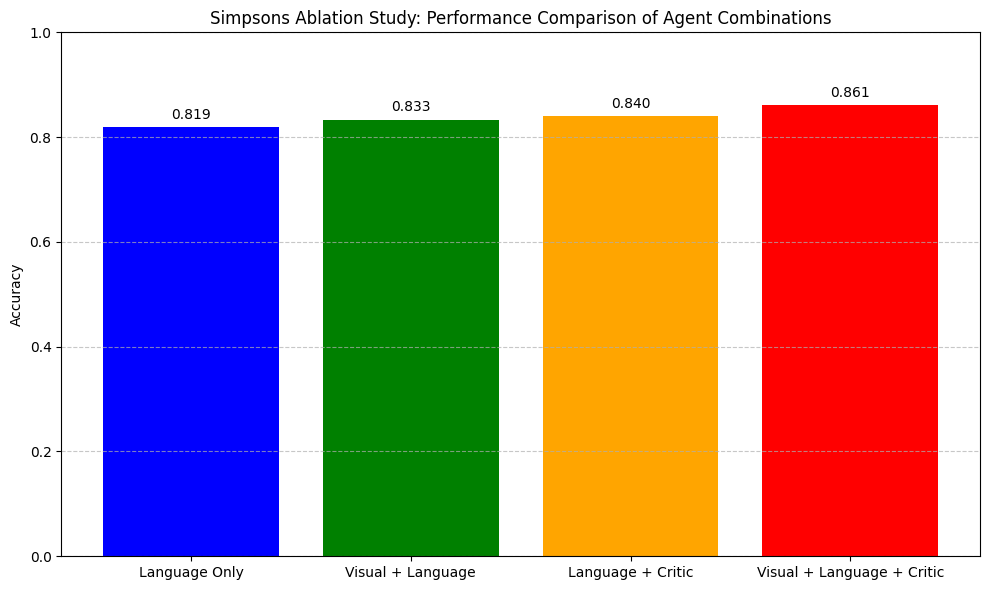


Comparison results saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_comparison.csv
Final comparison data:
                Configuration  Accuracy
0               Language Only  0.819444
1           Visual + Language  0.833333
2           Language + Critic  0.840278
3  Visual + Language + Critic  0.861111


In [22]:
# Create visualization of ablation results
# Check if all_accuracies has values - if not, try to load them from CSV files
if not all_accuracies:
    print("No accuracy results in memory. Attempting to load from CSV files...")
    
    # Define configuration names we expect to find
    expected_configs = [
        'language', 
        'visual_language', 
        'language_critic', 
        'visual_language_critic'
    ]
    
    # Safe model name for file pattern matching
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), os.path.join(results_dir, "ablation"))
    
    # Load accuracies from CSV files if they exist
    for config in expected_configs:
        file_path = os.path.join(results_dir, f'simpsons_ablation_{config}_{safe_model_name}.csv')
        try:
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                # Get the last row which should be the Average row
                avg_row = df[df['question_id'] == 'Average']
                if not avg_row.empty and 'accuracy' in avg_row.columns:
                    all_accuracies[config] = float(avg_row['accuracy'].iloc[0])
                    print(f"Loaded accuracy for {config}: {all_accuracies[config]:.4f}")
                else:
                    # Calculate average from individual rows
                    regular_rows = df[df['question_id'] != 'Average']
                    if not regular_rows.empty and 'accuracy' in regular_rows.columns:
                        all_accuracies[config] = float(regular_rows['accuracy'].mean())
                        print(f"Calculated accuracy for {config}: {all_accuracies[config]:.4f}")
        except Exception as e:
            print(f"Error loading results for {config}: {e}")

# If we still don't have accuracy values, use the ones from the notebook state
# or use placeholder values for demonstration
if not all_accuracies and 'accuracies' in globals() and accuracies:
    # Use the current experiment's results if available
    avg_accuracy = np.mean(accuracies) if accuracies else 0
    config_name = ''
    if ENABLE_VISUAL_AGENT:
        config_name += 'visual_'
    if ENABLE_LANGUAGE_AGENT:
        config_name += 'language'
    if ENABLE_CRITIC_AGENT:
        config_name += '_critic'
    
    if config_name:
        all_accuracies[config_name] = avg_accuracy
        print(f"Using current experiment accuracy for {config_name}: {avg_accuracy:.4f}")

# Create the results dictionary for visualization
results = {
    "Language Only": all_accuracies.get('language', 0),
    "Visual + Language": all_accuracies.get('visual_language', 0),
    "Language + Critic": all_accuracies.get('language_critic', 0),
    "Visual + Language + Critic": all_accuracies.get('visual_language_critic', 0)
}

# Print the values we're using
print("\nAccuracy values used for visualization:")
for config, accuracy in results.items():
    print(f"{config}: {accuracy:.4f}")

# Create a folder to save figures if not exist
os.makedirs("saved_figures", exist_ok=True)

# Generate timestamp for unique figure name
timestamp = time.strftime("%Y%m%d_%H%M%S")
config_name = f"ablation_comparison_{timestamp}"

# Create the visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Simpsons Ablation Study: Performance Comparison of Agent Combinations')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure with a unique name
plt.savefig(f"saved_figures/simpsons_{config_name}_comparison_plot.png", dpi=300)
print(f"Visualization saved to: saved_figures/{config_name}_comparison_plot.png")

plt.show()

# Save the comparison results to CSV
comparison_df = pd.DataFrame([results], index=['Accuracy']).T.reset_index()
comparison_df.columns = ['Configuration', 'Accuracy']
comparison_path = os.path.join(os.getcwd(), "results", "ablation", "simpsons_ablation_comparison.csv")

# Create results directory if it doesn't exist
os.makedirs(os.path.dirname(comparison_path), exist_ok=True)

# Save the comparison file
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison results saved to: {comparison_path}")
print(f"Final comparison data:\n{comparison_df}")